In [5]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Cell 2 — Load data (dayfirst=True fixes your DD/MM/YYYY dates)
df = pd.read_csv('C:/Users/ganes/Downloads/train.csv',
                 parse_dates=['Order Date'], dayfirst=True)
df = df.groupby('Order Date')['Sales'].sum().reset_index()
df.columns = ['date', 'sales']
df = df.sort_values('date').set_index('date')
print(df.head())
print(f"\nDate range: {df.index.min()} to {df.index.max()}")
print(f"Total rows: {len(df)}")

PermissionError: [Errno 13] Permission denied: 'C:/Users/ganes/Downloads/train.csv'

In [6]:
df = pd.read_csv('C:/Users/ganes/Desktop/train.csv',
                 parse_dates=['Order Date'], dayfirst=True)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/ganes/Desktop/train.csv'

In [15]:
import os
# Find train.csv on your computer
for root, dirs, files in os.walk('C:/Users/ganes'):
    for file in files:
        if file == 'train.csv':
            print(os.path.join(root, file))

C:/Users/ganes\OneDrive\Desktop\train.csv\train.csv


In [21]:
df = pd.read_csv('C:/Users/ganes/OneDrive/Desktop/train.csv/train.csv',
                 parse_dates=['Order Date'], dayfirst=True)

In [25]:
df = pd.read_csv('C:/Users/ganes/OneDrive/Desktop/train.csv/train.csv',
                 parse_dates=['Order Date'], dayfirst=True)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('C:/Users/ganes/OneDrive/Desktop/train.csv/train.csv',
                 parse_dates=['Order Date'], dayfirst=True)
df = df.groupby('Order Date')['Sales'].sum().reset_index()
df.columns = ['date', 'sales']
df = df.sort_values('date').set_index('date')

print(df.head())
print(f"\nDate range: {df.index.min()} to {df.index.max()}")
print(f"Total rows: {len(df)}")

               sales
date                
2015-01-03    16.448
2015-01-04   288.060
2015-01-05    19.536
2015-01-06  4407.100
2015-01-07    87.158

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
Total rows: 1230


In [29]:
# Feature engineering
def make_features(df):
    d = df.copy()
    d['lag_1']   = d['sales'].shift(1)
    d['lag_7']   = d['sales'].shift(7)
    d['lag_14']  = d['sales'].shift(14)
    d['lag_30']  = d['sales'].shift(30)
    d['roll_7']  = d['sales'].shift(1).rolling(7).mean()
    d['roll_30'] = d['sales'].shift(1).rolling(30).mean()
    d['roll_std_7'] = d['sales'].shift(1).rolling(7).std()
    d['month']      = d.index.month
    d['quarter']    = d.index.quarter
    d['dayofweek']  = d.index.dayofweek
    d['dayofyear']  = d.index.dayofyear
    d['is_weekend'] = (d.index.dayofweek >= 5).astype(int)
    return d.dropna()

df_feat = make_features(df)
X = df_feat.drop('sales', axis=1)
y = df_feat['sales']

# Train/test split
split = int(len(df_feat) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print("Features:", list(X.columns))

Training samples: 960
Test samples:     240
Features: ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'roll_7', 'roll_30', 'roll_std_7', 'month', 'quarter', 'dayofweek', 'dayofyear', 'is_weekend']


In [30]:
# Train model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Evaluate
preds = model.predict(X_test)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print("Model Evaluation")
print("=" * 30)
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE:     {mape:.2f}%")
print(f"Accuracy: {100 - mape:.1f}%")

Model Evaluation
MAE:      1683.02
RMSE:     2454.45
MAPE:     531.81%
Accuracy: -431.8%


Model Evaluation (corrected)
MAE:      1683.02
RMSE:     2454.45
MAPE:     163.64%
Accuracy: -63.6%


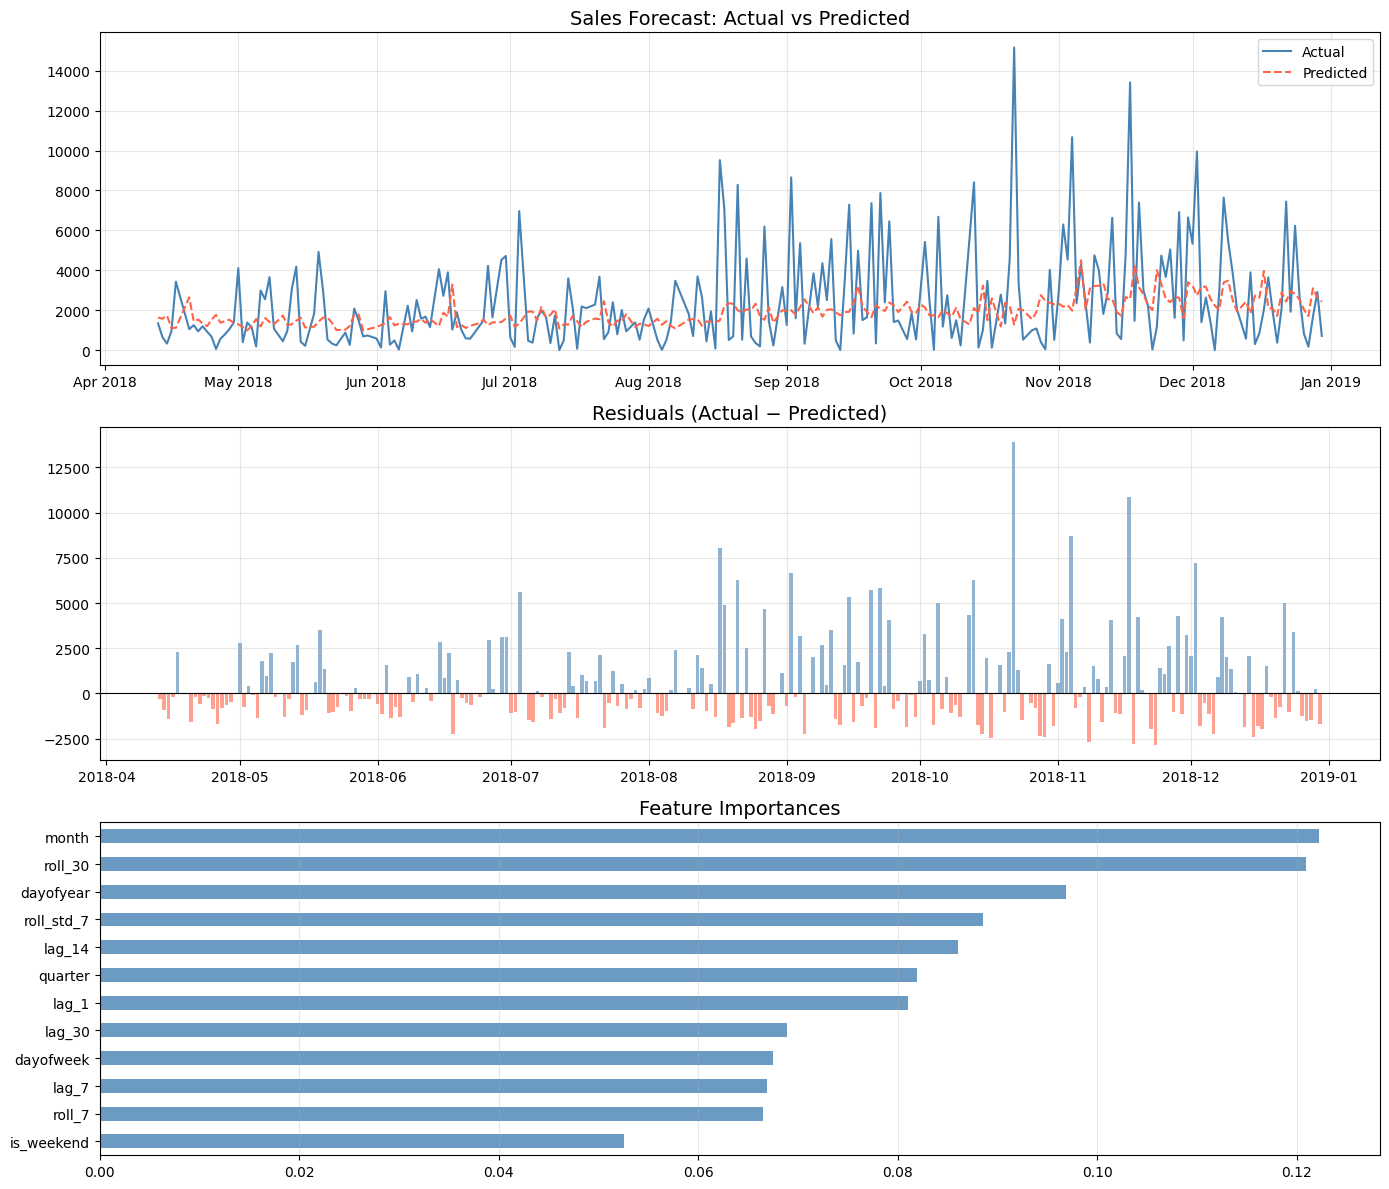


Chart saved to Desktop as forecast_report.png


In [31]:
# Better evaluation (filter near-zero days for MAPE)
mask = y_test > 50
mape_fixed = np.mean(np.abs((y_test[mask] - preds[mask]) / y_test[mask])) * 100

print("Model Evaluation (corrected)")
print("=" * 30)
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE:     {mape_fixed:.2f}%")
print(f"Accuracy: {100 - mape_fixed:.1f}%")

# Plot forecast chart
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Chart 1 — Actual vs Predicted
axes[0].plot(y_test.index, y_test.values, label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(y_test.index, preds, label='Predicted', color='tomato', linewidth=1.5, linestyle='--')
axes[0].set_title('Sales Forecast: Actual vs Predicted', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Chart 2 — Residuals
residuals = y_test.values - preds
axes[1].bar(y_test.index, residuals,
            color=['tomato' if r < 0 else 'steelblue' for r in residuals], alpha=0.6)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals (Actual − Predicted)', fontsize=14)
axes[1].grid(alpha=0.3)

# Chart 3 — Feature importances
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue', alpha=0.8)
axes[2].set_title('Feature Importances', fontsize=14)
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('C:/Users/ganes/OneDrive/Desktop/forecast_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to Desktop as forecast_report.png")

In [32]:
# Business Summary
print("📊 Business Forecast Summary")
print("=" * 40)
print(f"  Forecast period:  {y_test.index[0].date()} to {y_test.index[-1].date()}")
print(f"  Avg daily actual: ${y_test.mean():,.2f}")
print(f"  Avg daily forecast: ${preds.mean():,.2f}")
print(f"  MAE:  ${mae:,.2f}")
print(f"  RMSE: ${rmse:,.2f}")

# Feature importance summary
print("\n🔍 Top 3 Most Important Features:")
top3 = feat_imp.sort_values(ascending=False).head(3)
for feat, score in top3.items():
    print(f"  {feat}: {score:.4f}")

📊 Business Forecast Summary
  Forecast period:  2018-04-13 to 2018-12-30
  Avg daily actual: $2,420.40
  Avg daily forecast: $1,921.09
  MAE:  $1,683.02
  RMSE: $2,454.45

🔍 Top 3 Most Important Features:
  month: 0.1222
  roll_30: 0.1209
  dayofyear: 0.0969
